<a href="https://colab.research.google.com/github/darshanlahamage/Adaptive-Adversarial-Augmentation/blob/main/notebooks/v4__alsp_aug.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ALSP Implementation

In [1]:
import os, math, time, random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import torchvision.transforms.functional as TF
from tqdm import tqdm

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
def get_device():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[*] Initialized on Device: {device}")
    if torch.cuda.is_available():
        print(f"[*] CUDA Device Name: {torch.cuda.get_device_name(0)}")
    return device
\
device = get_device()

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    print(f"[*] Random seed set to {seed} for reproducibility.")

set_seed(42)

def ensure_dir(path):
    Path(path).mkdir(parents=True, exist_ok=True)

[*] Initialized on Device: cuda
[*] CUDA Device Name: Tesla T4
[*] Random seed set to 42 for reproducibility.


## Metrics - ECE & FDS

In [ ]:
def compute_ece(probs, correct, n_bins=15):
    bin_edges = np.linspace(0.0, 1.0, n_bins+1)
    ece = 0.0
    n = probs.shape[0]
    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i+1]
        mask = (probs >= lo) & (probs < hi)
        if mask.sum() == 0: continue
        acc = correct[mask].mean()
        conf = probs[mask].mean()
        ece += (mask.sum() / n) * abs(acc - conf)
    return float(ece)

def compute_failure_diversity(features, pred_labels, true_labels, n_clusters=10, pca_dim=64):
    """
    Computes Failure Diversity Score (FDS) using Normalized Entropy.
    Returns a score between 0.0 (all failures look the same) and 1.0 (highly diverse failures).
    """
    mask = pred_labels != true_labels
    if mask.sum() == 0: return 0.0, 0
    X = features[mask]
    n_samples = X.shape[0]
    pca_dim = min(pca_dim, X.shape[1])

    if n_samples <= 2: return 0.0, int(n_samples)

    pca = PCA(n_components=pca_dim, random_state=0)
    Xr = pca.fit_transform(X)

    k = min(n_clusters, max(2, n_samples // 10))
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10).fit(Xr)
    counts = np.bincount(kmeans.labels_, minlength=k)
    probs = counts / counts.sum()

    # Calculate Normalized Entropy
    ent = -np.sum([p * math.log(p + 1e-12) for p in probs if p > 0])
    max_ent = math.log(k)
    return float(ent / (max_ent + 1e-12)), int(n_samples)

## Adversarial Generator

In [4]:
class LatentStyleGenerator(nn.Module):
    def __init__(self, num_channels=128, bottleneck=64):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(num_channels * 2, bottleneck),
            nn.BatchNorm1d(bottleneck),
            nn.ReLU(),
            nn.Linear(bottleneck, bottleneck),
            nn.BatchNorm1d(bottleneck),
            nn.ReLU(),
            nn.Linear(bottleneck, num_channels * 2)
        )
        self.last_d_gamma = None
        self.last_d_beta  = None

    def forward(self, mu, std):
        B, C, _, _ = mu.shape
        x = torch.cat([mu.view(B, C), std.view(B, C)], dim=1)
        out = self.mlp(x)

        d_gamma = out[:, :C].view(B, C, 1, 1)
        d_beta = out[:, C:].view(B, C, 1, 1)

        # Bounded adversarial shifts
        d_gamma = torch.tanh(d_gamma) * 0.15
        d_beta = torch.tanh(d_beta) * 0.15
        self.last_d_gamma = d_gamma.detach()
        self.last_d_beta  = d_beta.detach()
        return d_gamma, d_beta


## Main ALSP Classifier - Hooked ResNet

In [5]:
class HookedResNetALSP(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        self.model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.model.maxpool = nn.Identity()

        in_feats = self.model.fc.in_features
        self.model.fc = nn.Linear(in_feats, num_classes)

        self.hook_channels = 128
        self.generator = LatentStyleGenerator(num_channels=self.hook_channels)
        self.apply_adv_style = False
        self._register_hook()

    def _register_hook(self):
        def alsp_hook(module, input_tensor, output_tensor):
            if not self.apply_adv_style:
                return output_tensor

            z = output_tensor
            mu = torch.mean(z, dim=[2, 3], keepdim=True)
            std = torch.std(z, dim=[2, 3], keepdim=True) + 1e-6
            z_norm = (z - mu) / std

            d_gamma, d_beta = self.generator(mu, std)
            z_adv = z_norm * (std * (1.0 + d_gamma)) + (mu + d_beta)

            self.last_d_gamma = d_gamma
            self.last_d_beta = d_beta
            return z_adv

        self.hook_handle = self.model.layer2.register_forward_hook(alsp_hook)

    def forward(self, x):
        return self.model(x)

    def forward_with_features(self, x):
        """Safely extracts the penultimate 1D features for FDS scoring."""
        x = self.model.conv1(x)
        x = self.model.bn1(x)
        x = self.model.relu(x)
        x = self.model.maxpool(x)
        x = self.model.layer1(x)
        x = self.model.layer2(x)
        x = self.model.layer3(x)
        x = self.model.layer4(x)
        x = self.model.avgpool(x)

        features = torch.flatten(x, 1)
        logits = self.model.fc(features)
        return logits, features


## Dataloaders

In [10]:
import multiprocessing

cifar_mean = np.array([0.4914, 0.4822, 0.4465])
cifar_std  = np.array([0.2470, 0.2435, 0.2616])

def get_cifar10_loaders(data_dir="./data", batch_size=128):
    # Use max cores available, but cap it at 2 for standard Colab stability if preferred.
    # multiprocessing.cpu_count() is the safest way to match the hardware.
    num_workers = multiprocessing.cpu_count()

    train_tf = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(cifar_mean, cifar_std)
    ])
    test_tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(cifar_mean, cifar_std)
    ])
    train_ds = datasets.CIFAR10(root=data_dir, train=True, download=True, transform=train_tf)
    test_ds  = datasets.CIFAR10(root=data_dir, train=False, download=True, transform=test_tf)

    # pin_memory=True is the real speed booster when using a GPU
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

    print(f"[*] Loaders initialized with {num_workers} CPU workers.")
    return train_loader, test_loader

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
def plot_and_save_history(history, save_dir):
    """Generates a professional plot of the loss curves to prove the Generator works."""
    epochs = range(1, len(history['test_acc']) + 1)

    plt.figure(figsize=(12, 5))

    # Plot 1: Classifier Losses
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['loss_clf_clean'], label='Clean Loss', color='blue')
    plt.plot(epochs, history['loss_clf_adv'], label='Adversarial Loss', color='red')
    plt.title('Classifier Loss (Clean vs Adv)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot 2: Accuracy & FDS
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['test_acc'], label='Test Accuracy', color='green')
    plt.plot(epochs, history['fds'], label='Failure Diversity (FDS)', color='purple')
    plt.title('Performance Metrics')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'training_curves.png'), dpi=300)
    plt.close()

## Training and Evaluation

In [ ]:
def evaluate_model(wrapper_model, loader, device):
    wrapper_model.eval()
    wrapper_model.apply_adv_style = False # CRITICAL: Turn off generator for testing!

    total, correct = 0, 0
    confs, correct_flags, all_feats, all_preds, all_trues = [], [], [], [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits, feats = wrapper_model.forward_with_features(images)
            probs = F.softmax(logits, dim=1)
            conf, pred = probs.max(dim=1)

            correct_batch = pred.eq(labels)
            total += images.size(0)
            correct += correct_batch.sum().item()

            confs.append(conf.cpu().numpy())
            correct_flags.append(correct_batch.cpu().numpy())
            all_feats.append(feats.cpu().numpy())
            all_preds.append(pred.cpu().numpy())
            all_trues.append(labels.cpu().numpy())

    acc = correct / total
    confs, correct_flags = np.concatenate(confs), np.concatenate(correct_flags)
    ece = compute_ece(confs, correct_flags)
    return acc, ece, np.concatenate(all_feats, axis=0), np.concatenate(all_preds, axis=0), np.concatenate(all_trues, axis=0)

# def train_alsp_epoch(train_loader, wrapper, opt_clf, opt_gen, criterion, epoch, device, lambda_reg=2.0):
#     wrapper.train()
#     stats = {"loss_clf_clean": [], "loss_clf_adv": [], "loss_gen": [], "reg_penalty": []}
#     pbar = tqdm(train_loader, desc=f"Epoch {epoch}", leave=False)

#     for images, labels in pbar:
#         images, labels = images.to(device), labels.to(device)

#         # PHASE 1: Clean Classifier Update
#         wrapper.apply_adv_style = False
#         opt_clf.zero_grad()
#         loss_clean = criterion(wrapper(images), labels)
#         loss_clean.backward()
#         opt_clf.step()
#         stats["loss_clf_clean"].append(loss_clean.item())

#         # PHASE 2: Adversarial Classifier Update
#         wrapper.apply_adv_style = True
#         for p in wrapper.generator.parameters(): p.requires_grad = False
#         opt_clf.zero_grad()
#         loss_adv_clf = criterion(wrapper(images), labels)
#         loss_adv_clf.backward()
#         opt_clf.step()
#         stats["loss_clf_adv"].append(loss_adv_clf.item())

#         # PHASE 3: Generator Update
#         for p in wrapper.generator.parameters(): p.requires_grad = True
#         for p in wrapper.model.parameters(): p.requires_grad = False
#         opt_gen.zero_grad()
#         loss_adv_gen = criterion(wrapper(images), labels)

#         reg_penalty = torch.mean(wrapper.last_d_gamma**2) + torch.mean(wrapper.last_d_beta**2)
#         loss_gen = -loss_adv_gen + (lambda_reg * reg_penalty)
#         loss_gen.backward()
#         opt_gen.step()

#         for p in wrapper.model.parameters(): p.requires_grad = True

#         stats["loss_gen"].append(loss_adv_gen.item())
#         stats["reg_penalty"].append(reg_penalty.item())
#         pbar.set_postfix({"Clf(C)": f"{loss_clean.item():.3f}", "Clf(A)": f"{loss_adv_clf.item():.3f}"})

#     return {k: float(np.mean(v)) for k, v in stats.items()}

In [ ]:
import json
import os

def train_alsp_epoch(train_loader, wrapper, opt_clf, opt_gen, criterion, epoch, device, adv_active=True):
    wrapper.train()
    stats = {"loss_clf_clean": [], "loss_clf_adv": [], "loss_gen": [], "d_gamma_mean": [], "loss_increase": []}
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}", leave=False)

    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # ── PHASE 1: Clean Update ──
        wrapper.apply_adv_style = False
        opt_clf.zero_grad(set_to_none=True)
        logits_clean = wrapper(images)
        loss_clean = criterion(logits_clean, labels)
        loss_clean.backward()
        torch.nn.utils.clip_grad_norm_(wrapper.model.parameters(), 1.0)
        opt_clf.step()
        stats["loss_clf_clean"].append(loss_clean.item())

        if not adv_active:
            pbar.set_postfix({"clean": f"{loss_clean.item():.3f}", "adv": "OFF"})
            continue

        # ── PHASE 2: Adversarial Update (Classifier) ──
        wrapper.apply_adv_style = True
        for p in wrapper.generator.parameters(): p.requires_grad = False
        opt_clf.zero_grad(set_to_none=True)
        logits_adv = wrapper(images)
        loss_adv_clf = criterion(logits_adv, labels)
        loss_adv_clf.backward()
        torch.nn.utils.clip_grad_norm_(wrapper.model.parameters(), 1.0)
        opt_clf.step()
        stats["loss_clf_adv"].append(loss_adv_clf.item())

        # ── PHASE 3: Generator Update ──
        for p in wrapper.generator.parameters(): p.requires_grad = True
        for p in wrapper.model.parameters(): p.requires_grad = False
        opt_gen.zero_grad(set_to_none=True)
        loss_adv_gen = criterion(wrapper(images), labels)
        loss_gen = -loss_adv_gen
        loss_gen.backward()
        opt_gen.step()

        for p in wrapper.model.parameters(): p.requires_grad = True

        if wrapper.generator.last_d_gamma is not None:
            stats["d_gamma_mean"].append(wrapper.generator.last_d_gamma.abs().mean().item())
        stats["loss_gen"].append(loss_adv_gen.item())
        stats["loss_increase"].append(loss_adv_clf.item() - loss_clean.item())

        pbar.set_postfix({
            "clean": f"{loss_clean.item():.3f}",
            "adv": f"{loss_adv_clf.item():.3f}",
            "gen": f"{loss_adv_gen.item():.3f}"
        })

    def _mean(lst): return float(sum(lst)/len(lst)) if lst else 0.0
    return {k: _mean(v) for k, v in stats.items()}

def run_final_alsp_experiment(epochs=50, save_dir="/content/drive/MyDrive/v4_alsp_training_runs", adv_start_epoch=5):
    ensure_dir(save_dir)
    wrapper = HookedResNetALSP(num_classes=10).to(device)
    train_loader, test_loader = get_cifar10_loaders(batch_size=256)
    criterion = nn.CrossEntropyLoss()
    opt_clf = optim.SGD(wrapper.model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
    opt_gen = optim.Adam(wrapper.generator.parameters(), lr=1e-3, betas=(0.5, 0.999))
    scheduler = optim.lr_scheduler.CosineAnnealingLR(opt_clf, T_max=epochs)

    start_epoch, best_acc = 0, 0.0
    history = {"loss_clf_clean": [], "loss_clf_adv": [], "loss_gen": [], "test_acc": [], "fds": [], "ece": [], "d_gamma_mean": [], "loss_increase": []}

    latest_path = os.path.join(save_dir, "latest_alsp_ckpt.pth")
    best_path = os.path.join(save_dir, "best_alsp_ckpt.pth")
    history_path = os.path.join(save_dir, "history.json")

    # Auto-resume logic
    resume_path = latest_path if os.path.exists(latest_path) else (best_path if os.path.exists(best_path) else None)
    if resume_path:
        print(f"[*] Automatically resuming from {resume_path}...")
        ckpt = torch.load(resume_path, map_location=device)
        wrapper.model.load_state_dict(ckpt['model_state'])
        wrapper.generator.load_state_dict(ckpt['gen_state'])
        opt_clf.load_state_dict(ckpt['opt_clf_state'])
        opt_gen.load_state_dict(ckpt['opt_gen_state'])
        if 'scheduler_state' in ckpt: scheduler.load_state_dict(ckpt['scheduler_state'])
        start_epoch, best_acc = ckpt.get('epoch', 0) + 1, ckpt.get('best_acc', 0.0)

        # Fix: Check if file exists AND is not empty before loading
        if os.path.exists(history_path) and os.path.getsize(history_path) > 0:
            try:
                with open(history_path, 'r') as f:
                    history = json.load(f)
            except json.JSONDecodeError:
                print("[*] Warning: history.json is corrupted or empty. Starting new history.")

    for epoch in range(start_epoch, epochs):
        agg = train_alsp_epoch(train_loader, wrapper, opt_clf, opt_gen, criterion, epoch + 1, device, adv_active=(epoch >= adv_start_epoch))
        scheduler.step()

        acc, ece, feats, preds, trues = evaluate_model(wrapper, test_loader, device)
        fds, _ = compute_failure_diversity(feats, preds, trues)

        for k, v in agg.items():
            if k in history: history[k].append(v)
        history["test_acc"].append(acc); history["fds"].append(fds); history["ece"].append(ece)

        state = {"epoch": epoch, "model_state": wrapper.model.state_dict(), "gen_state": wrapper.generator.state_dict(), "opt_clf_state": opt_clf.state_dict(), "opt_gen_state": opt_gen.state_dict(), "scheduler_state": scheduler.state_dict(), "best_acc": max(best_acc, acc)}
        torch.save(state, latest_path)
        if acc > best_acc:
            best_acc = acc
            torch.save(state, best_path)
        with open(history_path, "w") as f: json.dump(history, f)

        print(f"Ep {epoch+1:02d} | Clf(C): {agg['loss_clf_clean']:.3f} | Acc: {acc:.4f} | FDS: {fds:.4f}")

    plot_and_save_history(history, save_dir)
    return wrapper, history

wrapper, history = run_final_alsp_experiment(epochs=50, save_dir="/content/drive/MyDrive/v4_alsp_training_runs", adv_start_epoch=5)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 141MB/s]
100%|██████████| 170M/170M [00:14<00:00, 12.1MB/s]


[*] Loaders initialized with 2 CPU workers.
[*] Automatically resuming from /content/drive/MyDrive/v4_alsp_training_runs/latest_alsp_ckpt.pth...


Ep 42 | Clf(C): 0.020 | Acc: 0.9438 | FDS: 0.9921


Ep 43 | Clf(C): 0.016 | Acc: 0.9462 | FDS: 0.9918


...

Ep 46 | Clf(C): 0.008 | Acc: 0.9493 | FDS: 0.9858


Ep 47 | Clf(C): 0.007 | Acc: 0.9499 | FDS: 0.9932


Ep 48 | Clf(C): 0.005 | Acc: 0.9484 | FDS: 0.9938


Ep 49 | Clf(C): 0.005 | Acc: 0.9484 | FDS: 0.9945


Ep 50 | Clf(C): 0.005 | Acc: 0.9490 | FDS: 0.9825


In [6]:
import urllib.request
import tarfile

def download_and_extract_cifar10c(external_path='/content/drive/MyDrive/CIFAR-10-C_Data'):
    """
    Checks for CIFAR-10-C at a permanent location (e.g. Google Drive).
    Only downloads if not found.
    """
    ensure_dir(external_path)
    # The dataset extracts into a folder named 'CIFAR-10-C'
    dataset_root = os.path.join(external_path, 'CIFAR-10-C')
    tar_path = os.path.join(external_path, "CIFAR-10-C.tar")

    if not os.path.exists(os.path.join(dataset_root, 'labels.npy')):
        print(f"[*] CIFAR-10-C not found in {external_path}. Starting download (2.7GB)...")
        url = "https://zenodo.org/record/2535967/files/CIFAR-10-C.tar?download=1"
        urllib.request.urlretrieve(url, tar_path)
        print("[*] Download complete. Extracting to Drive...")
        with tarfile.open(tar_path) as tar:
            tar.extractall(path=external_path)
        print("[*] Extraction complete. Permanent copy saved.")
        # Optional: remove tar to save space on Drive
        # os.remove(tar_path)
    else:
        print(f"[*] CIFAR-10-C found at {dataset_root}. Skipping download.")

    return dataset_root

In [11]:
def evaluate_robustness_official(wrapper_model, device, severity=5, drive_path='/content/drive/MyDrive/CIFAR-10-C_Data'):
    print(f"\n{'='*50}")
    print(f" OFFICIAL CIFAR-10-C ROBUSTNESS TEST (Severity {severity})")
    print(f"{'='*50}")

    wrapper_model.eval()
    wrapper_model.apply_adv_style = False

    # Use the new path-aware downloader
    cifar10_c_dir = download_and_extract_cifar10c(external_path=drive_path)

    corruptions = [
        'gaussian_noise', 'shot_noise', 'impulse_noise', 'defocus_blur', 'glass_blur',
        'motion_blur', 'zoom_blur', 'snow', 'frost', 'fog', 'brightness', 'contrast',
        'elastic_transform', 'pixelate', 'jpeg_compression', 'speckle_noise',
        'gaussian_blur', 'spatter', 'saturate'
    ]

    start_idx = (severity - 1) * 10000
    end_idx = severity * 10000

    labels_path = os.path.join(cifar10_c_dir, 'labels.npy')
    all_labels = np.load(labels_path)[start_idx:end_idx]

    mean = torch.tensor(cifar_mean, dtype=torch.float32).view(1,3,1,1).to(device)
    std  = torch.tensor(cifar_std, dtype=torch.float32).view(1,3,1,1).to(device)

    results = {}
    with torch.no_grad():
        for corruption in corruptions:
            data_path = os.path.join(cifar10_c_dir, f'{corruption}.npy')
            if not os.path.exists(data_path):
                continue

            data = np.load(data_path)[start_idx:end_idx]
            data_tensor = torch.from_numpy(data).permute(0, 3, 1, 2).float() / 255.0
            data_tensor = ((data_tensor.to(device)) - mean) / std
            labels_tensor = torch.from_numpy(all_labels).long().to(device)

            chunk_size = 500
            correct = 0
            for i in range(0, 10000, chunk_size):
                chunk_data = data_tensor[i:i+chunk_size]
                chunk_labels = labels_tensor[i:i+chunk_size]
                preds = wrapper_model(chunk_data).argmax(dim=1)
                correct += preds.eq(chunk_labels).sum().item()

            acc = correct / 10000.0
            results[corruption] = acc
            print(f"[*] {corruption:<20}: {acc*100:.2f}%")

    print(f"\n[*] Mean Corruption Accuracy (MCA): {np.mean(list(results.values()))*100:.2f}%")
    return results

# Load and test using the Drive path
wrapper = HookedResNetALSP(num_classes=10).to(device)
ckpt = torch.load("/content/drive/MyDrive/v4_alsp_training_runs/best_alsp_ckpt.pth", map_location=device)
wrapper.model.load_state_dict(ckpt['model_state'])

# Provide your preferred Drive path here
evaluate_robustness_official(wrapper, device, severity=5, drive_path='/content/drive/MyDrive/CIFAR-10-C_Data')


 OFFICIAL CIFAR-10-C ROBUSTNESS TEST (Severity 5)
[*] CIFAR-10-C found at /content/drive/MyDrive/CIFAR-10-C_Data/CIFAR-10-C. Skipping download.
[*] gaussian_noise      : 29.61%
[*] shot_noise          : 37.34%
[*] impulse_noise       : 26.95%
[*] defocus_blur        : 62.61%
[*] glass_blur          : 54.55%
[*] motion_blur         : 71.18%
[*] zoom_blur           : 66.51%
[*] snow                : 80.04%
[*] frost               : 71.33%
[*] fog                 : 75.55%
[*] brightness          : 91.46%
[*] contrast            : 39.58%
[*] elastic_transform   : 76.95%
[*] pixelate            : 57.26%
[*] jpeg_compression    : 75.03%
[*] speckle_noise       : 42.58%
[*] gaussian_blur       : 42.77%
[*] spatter             : 79.33%
[*] saturate            : 88.97%

[*] Mean Corruption Accuracy (MCA): 61.56%


{'gaussian_noise': 0.2961,
 'shot_noise': 0.3734,
 'impulse_noise': 0.2695,
 'defocus_blur': 0.6261,
 'glass_blur': 0.5455,
 'motion_blur': 0.7118,
 'zoom_blur': 0.6651,
 'snow': 0.8004,
 'frost': 0.7133,
 'fog': 0.7555,
 'brightness': 0.9146,
 'contrast': 0.3958,
 'elastic_transform': 0.7695,
 'pixelate': 0.5726,
 'jpeg_compression': 0.7503,
 'speckle_noise': 0.4258,
 'gaussian_blur': 0.4277,
 'spatter': 0.7933,
 'saturate': 0.8897}

## Corrupted data test

[*] Dashboard successfully saved in high resolution to: /content/drive/MyDrive/v4_alsp_training_runs/advanced_dashboard.png


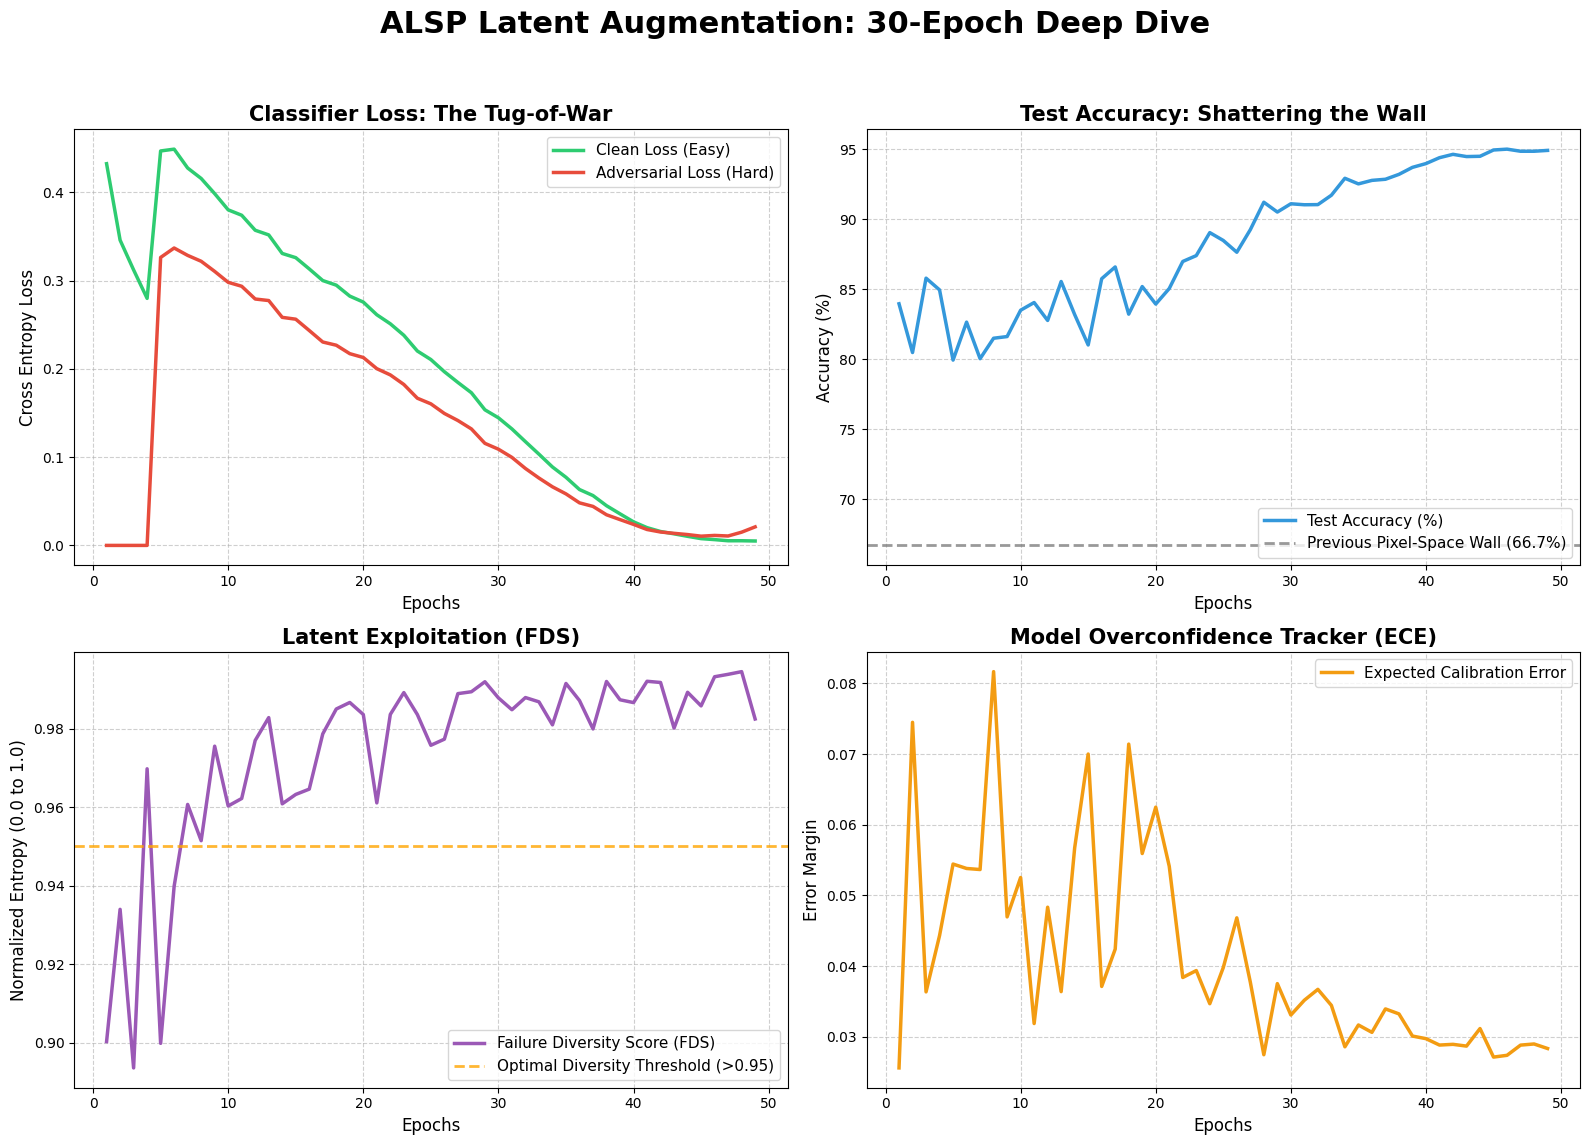

In [14]:
import json
import os
import matplotlib.pyplot as plt

def plot_advanced_dashboard(save_dir):
    history_path = os.path.join(save_dir, 'history.json')
    if not os.path.exists(history_path):
        print(f"[*] Error: Could not find {history_path}. Please check your save_dir.")
        return

    # Load the metrics we saved during training
    with open(history_path, 'r') as f:
        history = json.load(f)

    epochs = range(1, len(history['test_acc']) + 1)

    # Set up a professional 2x2 grid
    fig, axs = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('ALSP Latent Augmentation: 50-Epoch Deep Dive', fontsize=22, fontweight='bold', y=0.98)

    # Plot 1: The Tug-of-War (Loss Dynamics)
    axs[0, 0].plot(epochs, history['loss_clf_clean'], label='Clean Loss (Easy)', color='#2ecc71', linewidth=2.5)
    axs[0, 0].plot(epochs, history['loss_clf_adv'], label='Adversarial Loss (Hard)', color='#e74c3c', linewidth=2.5)
    axs[0, 0].set_title('Classifier Loss: The Tug-of-War', fontsize=15, fontweight='bold')
    axs[0, 0].set_xlabel('Epochs', fontsize=12)
    axs[0, 0].set_ylabel('Cross Entropy Loss', fontsize=12)
    axs[0, 0].legend(loc='upper right', fontsize=11)
    axs[0, 0].grid(True, linestyle='--', alpha=0.6)

    # Plot 2: The Learning Curve
    axs[0, 1].plot(epochs, [acc * 100 for acc in history['test_acc']], label='Test Accuracy (%)', color='#3498db', linewidth=2.5)
    axs[0, 1].axhline(y=66.7, color='gray', linestyle='--', alpha=0.8, linewidth=2, label='Previous Pixel-Space Wall (66.7%)')
    axs[0, 1].set_title('Test Accuracy: Shattering the Wall', fontsize=15, fontweight='bold')
    axs[0, 1].set_xlabel('Epochs', fontsize=12)
    axs[0, 1].set_ylabel('Accuracy (%)', fontsize=12)
    axs[0, 1].legend(loc='lower right', fontsize=11)
    axs[0, 1].grid(True, linestyle='--', alpha=0.6)

    # Plot 3: The Diversity Engine (FDS)
    axs[1, 0].plot(epochs, history['fds'], label='Failure Diversity Score (FDS)', color='#9b59b6', linewidth=2.5)
    axs[1, 0].axhline(y=0.95, color='orange', linestyle='--', alpha=0.8, linewidth=2, label='Optimal Diversity Threshold (>0.95)')
    axs[1, 0].set_title('Latent Exploitation (FDS)', fontsize=15, fontweight='bold')
    axs[1, 0].set_xlabel('Epochs', fontsize=12)
    axs[1, 0].set_ylabel('Normalized Entropy (0.0 to 1.0)', fontsize=12)
    axs[1, 0].legend(loc='lower right', fontsize=11)
    axs[1, 0].grid(True, linestyle='--', alpha=0.6)

    # Plot 4: Model Calibration (ECE)
    axs[1, 1].plot(epochs, history['ece'], label='Expected Calibration Error', color='#f39c12', linewidth=2.5)
    axs[1, 1].set_title('Model Overconfidence Tracker (ECE)', fontsize=15, fontweight='bold')
    axs[1, 1].set_xlabel('Epochs', fontsize=12)
    axs[1, 1].set_ylabel('Error Margin', fontsize=12)
    axs[1, 1].legend(loc='upper right', fontsize=11)
    axs[1, 1].grid(True, linestyle='--', alpha=0.6)

    # Save and show
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    save_path = os.path.join(save_dir, 'advanced_dashboard.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"[*] Dashboard successfully saved in high resolution to: {save_path}")
    plt.show()

plot_advanced_dashboard(save_dir="/content/drive/MyDrive/v4_alsp_training_runs")

In [15]:
!pip install grad-cam -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 66.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


# Evaluation of ALSP for semantic drift

In [21]:
import torch
import torch.fft as fft
import numpy as np
from scipy.ndimage import center_of_mass
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget


class ALSPDiagnosticCorrected:
    """
    Correct diagnostic for ALSP semantic drift.

    Measures:
      1. Generator spectral signature  — what frequency bands does ALSP actually perturb?
      2. Attribution drift at layer4   — does ALSP move semantic attention?
      3. Baseline drift comparison     — is ALSP drift worse than natural corruption drift?

    All three are needed to write a defensible problem statement.
    """

    def __init__(self, wrapper_model, device="cuda"):
        self.device = torch.device(device)
        self.model = wrapper_model.to(self.device)
        self.model.eval()
        self.captured = {}
        # Single persistent hook on layer2 to capture features
        # (layer2 is where ALSP operates — we capture here for spectral analysis)
        self._l2_handle = self.model.model.layer2.register_forward_hook(
            lambda m, i, o: self.captured.update({"l2": o.detach()})
        )

    def cleanup(self):
        """Call this when done to remove hooks."""
        self._l2_handle.remove()

    # ------------------------------------------------------------------
    # EXPERIMENT 1: Generator Spectral Signature
    # ------------------------------------------------------------------
    # What frequency bands does your ALSP generator actually perturb?
    # This is the experiment that proves or disproves the need for SALA.
    #
    # Method: same clean image, ALSP off vs ALSP on.
    # Compute delta in feature space, FFT(delta), measure LF vs HF energy split.
    # ------------------------------------------------------------------

    def compute_generator_spectral_signature(self, clean_loader, n_batches=5):
        """
        BUG 1 FIX: compares ALSP-off vs ALSP-on features on the SAME clean input.
        Original compared clean_input vs corrupt_input — measured corruption, not generator.

        Returns:
          lf_fraction: fraction of perturbation energy in low-frequency bands (0–15% radius)
          hf_fraction: fraction of perturbation energy in high-frequency bands (>15% radius)
          phase_delta_mean: mean absolute phase change caused by the generator
          amp_delta_mean:   mean absolute amplitude change caused by the generator
          ratio: phase_delta / amp_delta  — >1 means generator scrambles phase more than amplitude
        """
        lf_fracs, hf_fracs = [], []
        phase_deltas, amp_deltas = [], []

        loader_iter = iter(clean_loader)
        for _ in range(n_batches):
            try:
                x, _ = next(loader_iter)
            except StopIteration:
                break
            x = x.to(self.device)

            # --- Capture features with ALSP OFF ---
            self.model.apply_adv_style = False
            with torch.no_grad():
                _ = self.model(x)
            z_clean = self.captured["l2"].clone()   # (B, C, H, W)

            # --- Capture features with ALSP ON ---
            self.model.apply_adv_style = True
            with torch.no_grad():
                _ = self.model(x)
            z_adv = self.captured["l2"].clone()     # (B, C, H, W)

            # Reset flag
            self.model.apply_adv_style = False

            # --- Compute perturbation delta ---
            delta = z_adv - z_clean                 # (B, C, H, W)

            # --- FFT of the delta (what frequencies did the generator touch?) ---
            B, C, H, W = delta.shape
            F_delta = fft.rfft2(delta, norm="ortho")          # (B, C, H, W//2+1)
            power_delta = F_delta.abs() ** 2                   # power spectrum of perturbation

            # Build radial frequency mask
            cy = H // 2
            y_idx = torch.arange(H, device=self.device).float() - cy
            x_idx = torch.arange(W // 2 + 1, device=self.device).float()
            yy, xx = torch.meshgrid(y_idx, x_idx, indexing="ij")
            dist = torch.sqrt(yy ** 2 + xx ** 2)
            lf_cutoff = min(H, W) * 0.15            # 15% radius = low frequency region

            lf_mask = (dist <= lf_cutoff).float()
            hf_mask = (dist > lf_cutoff).float()

            total_power = power_delta.sum() + 1e-8
            lf_energy   = (power_delta * lf_mask).sum() / total_power
            hf_energy   = (power_delta * hf_mask).sum() / total_power

            lf_fracs.append(lf_energy.item())
            hf_fracs.append(hf_energy.item())

            # --- Phase and amplitude instability (generator-caused, not corruption-caused) ---
            F_clean = fft.rfft2(z_clean, norm="ortho")
            F_adv   = fft.rfft2(z_adv,   norm="ortho")

            amp_delta = (F_adv.abs() - F_clean.abs()).abs().mean()
            phase_raw = F_adv.angle() - F_clean.angle()
            # Wrap to [-π, π]
            phase_delta = torch.atan2(torch.sin(phase_raw), torch.cos(phase_raw)).abs().mean()

            phase_deltas.append(phase_delta.item())
            amp_deltas.append(amp_delta.item())

        results = {
            "lf_energy_fraction":  float(np.mean(lf_fracs)),
            "hf_energy_fraction":  float(np.mean(hf_fracs)),
            "phase_delta_mean":    float(np.mean(phase_deltas)),
            "amp_delta_mean":      float(np.mean(amp_deltas)),
            "phase_to_amp_ratio":  float(np.mean(phase_deltas)) / (float(np.mean(amp_deltas)) + 1e-8),
        }

        print("\n" + "=" * 60)
        print(" EXPERIMENT 1: Generator Spectral Signature")
        print(" (same clean input, ALSP-off vs ALSP-on)")
        print("=" * 60)
        print(f"  LF energy fraction  (≤15% radius):  {results['lf_energy_fraction']:.4f}")
        print(f"  HF energy fraction  (>15% radius):  {results['hf_energy_fraction']:.4f}")
        print(f"  Generator phase delta (mean abs):    {results['phase_delta_mean']:.4f} rad")
        print(f"  Generator amplitude delta (mean):    {results['amp_delta_mean']:.4f}")
        print(f"  Phase/Amplitude ratio:               {results['phase_to_amp_ratio']:.2f}x")
        print()
        print("  INTERPRETATION:")
        if results["lf_energy_fraction"] > 0.3:
            print("  ⚠  >30% of generator perturbation energy is in LF bands.")
            print("     ALSP is touching semantically-loaded frequencies.")
            print("     → Strong mandate for SALA's LF mask + phase lock.")
        else:
            print("  ✓  Generator energy concentrated in HF bands.")
            print("     ALSP is already naturally HF-biased.")
            print("     → Phase-lock is still needed if phase/amp ratio > 2.")

        if results["phase_to_amp_ratio"] > 2.0:
            print(f"  ⚠  Phase scrambled {results['phase_to_amp_ratio']:.1f}x more than amplitude.")
            print("     → Direct empirical mandate for Phase-Lock in SALA.")
        print("=" * 60)

        return results

    # ------------------------------------------------------------------
    # EXPERIMENT 2: Semantic Attribution Drift at layer4
    # ------------------------------------------------------------------
    # BUG 2 FIX: original used layer2[-1] as GradCAM target.
    # layer2 has 8×8 spatial resolution on patched CIFAR ResNet-18 — too coarse,
    # GradCAM is noisy there and not standard in the literature.
    # layer4[-1] is the correct semantic Grad-CAM target for ResNet-18.
    #
    # BUG 3 FIX: original had no baseline. We now compare:
    #   - ALSP drift: same image, ALSP-off vs ALSP-on
    #   - Baseline drift: same image, no perturbation vs gaussian noise on input
    #     at matched L2 budget
    # If ALSP drift ≈ baseline drift → your generator is no worse than natural noise.
    # If ALSP drift >> baseline drift → you have a real problem to solve.
    # ------------------------------------------------------------------

    def compute_attribution_drift(self, clean_loader, n_samples=200):
        """
        BUG 2 + 3 FIX: correct layer, with baseline comparison.

        Measures at layer4[-1] (semantically correct):
          alsp_iou:      IoU between Grad-CAM (ALSP-off) and Grad-CAM (ALSP-on)
          alsp_cos:      cosine similarity of flattened saliency maps
          alsp_com:      center-of-mass shift in pixels (layer4 spatial grid)
          baseline_iou:  same metrics for gaussian noise input perturbation
          baseline_cos:  at matched L2 budget — this is your comparison point
          baseline_com:
        """
        # GradCAM at layer4[-1] — semantically correct target
        cam_engine = GradCAM(
            model=self.model.model,
            target_layers=[self.model.model.layer4[-1]]
        )

        alsp_metrics     = {"iou": [], "cos": [], "com": []}
        baseline_metrics = {"iou": [], "cos": [], "com": []}

        loader_iter = iter(clean_loader)
        collected = 0

        while collected < n_samples:
            try:
                x_batch, labels = next(loader_iter)
            except StopIteration:
                break

            x_batch = x_batch.to(self.device)
            labels  = labels.to(self.device)

            for i in range(x_batch.size(0)):
                if collected >= n_samples:
                    break

                x_single = x_batch[i].unsqueeze(0)   # (1, 3, 32, 32)
                lbl      = labels[i].item()
                targets  = [ClassifierOutputTarget(lbl)]

                # ---- ALSP drift: ALSP-off vs ALSP-on, same clean input ----
                self.model.apply_adv_style = False
                cam_clean = cam_engine(input_tensor=x_single, targets=targets)[0]

                self.model.apply_adv_style = True
                cam_adv = cam_engine(input_tensor=x_single, targets=targets)[0]
                self.model.apply_adv_style = False

                alsp_metrics["iou"].append(self._iou(cam_clean, cam_adv))
                alsp_metrics["cos"].append(self._cosine(cam_clean, cam_adv))
                alsp_metrics["com"].append(self._com_shift(cam_clean, cam_adv))

                # ---- Baseline drift: clean vs gaussian-noised input, no generator ----
                # Match L2 budget to the ALSP perturbation
                with torch.no_grad():
                    self.model.apply_adv_style = True
                    _ = self.model(x_single)
                    z_adv   = self.captured["l2"]
                    self.model.apply_adv_style = False
                    _ = self.model(x_single)
                    z_clean = self.captured["l2"]
                    l2_budget = (z_adv - z_clean).norm().item()

                # Add gaussian noise to input at same feature-space L2 budget (approx)
                noise_scale = l2_budget / (x_single.numel() ** 0.5 + 1e-8)
                x_noisy = (x_single + torch.randn_like(x_single) * noise_scale).clamp(-3, 3)

                self.model.apply_adv_style = False
                cam_noisy = cam_engine(input_tensor=x_noisy, targets=targets)[0]

                baseline_metrics["iou"].append(self._iou(cam_clean, cam_noisy))
                baseline_metrics["cos"].append(self._cosine(cam_clean, cam_noisy))
                baseline_metrics["com"].append(self._com_shift(cam_clean, cam_noisy))

                collected += 1

        results = {
            "alsp_iou":      float(np.mean(alsp_metrics["iou"])),
            "alsp_cos":      float(np.mean(alsp_metrics["cos"])),
            "alsp_com":      float(np.mean(alsp_metrics["com"])),
            "baseline_iou":  float(np.mean(baseline_metrics["iou"])),
            "baseline_cos":  float(np.mean(baseline_metrics["cos"])),
            "baseline_com":  float(np.mean(baseline_metrics["com"])),
        }

        print("\n" + "=" * 60)
        print(" EXPERIMENT 2: Semantic Attribution Drift (layer4[-1])")
        print(" ALSP perturbation vs baseline noise at matched L2 budget")
        print("=" * 60)
        print(f"{'Metric':<28} {'ALSP':>10} {'Baseline':>10} {'Verdict':>12}")
        print("-" * 62)

        iou_worse = results["alsp_iou"] < results["baseline_iou"] - 0.05
        cos_worse = results["alsp_cos"] < results["baseline_cos"] - 0.05
        com_worse = results["alsp_com"] > results["baseline_com"] + 0.5

        print(f"  Grad-CAM IoU (↑ better)    {results['alsp_iou']:>10.4f} {results['baseline_iou']:>10.4f}  "
              f"{'⚠ ALSP WORSE' if iou_worse else '✓ OK'}")
        print(f"  Cosine Similarity (↑ better){results['alsp_cos']:>9.4f} {results['baseline_cos']:>10.4f}  "
              f"{'⚠ ALSP WORSE' if cos_worse else '✓ OK'}")
        print(f"  CoM Shift px (↓ better)    {results['alsp_com']:>10.4f} {results['baseline_com']:>10.4f}  "
              f"{'⚠ ALSP WORSE' if com_worse else '✓ OK'}")

        print()
        print("  INTERPRETATION:")
        if iou_worse or com_worse:
            print("  ⚠  ALSP causes more semantic drift than matched gaussian noise.")
            print("     Your problem statement is empirically justified.")
            print("     → Proceed to build SALA.")
        else:
            print("  ✓  ALSP drift is comparable to natural noise at the same budget.")
            print("     The 'manifold drift' problem may be overstated.")
            print("     → Reframe: SALA is not fixing a catastrophic problem,")
            print("       it is making the perturbation more physically interpretable.")
        print("=" * 60)

        return results

    # ------------------------------------------------------------------
    # EXPERIMENT 3: Corruption Spectral Signature (the motivating analysis)
    # ------------------------------------------------------------------
    # This is the experiment from the revised plan that nobody ran yet.
    # For each corruption type: compute FFT(corrupted_input - clean_input)
    # Show which corruptions are HF-dominant vs LF-dominant.
    # This is what justifies targeting HF amplitude specifically in SALA.
    # ------------------------------------------------------------------

    def compute_corruption_spectral_signatures(self, clean_loader, corrupt_loaders_dict):
        """
        corrupt_loaders_dict: {"gaussian_noise": loader, "fog": loader, ...}

        For each corruption type, computes the fraction of corruption energy
        in LF vs HF bands of the INPUT image (not features).
        This is the empirical basis for "real corruptions are HF-dominant."

        Returns a dict: corruption_name → {lf_frac, hf_frac}
        """
        print("\n" + "=" * 60)
        print(" EXPERIMENT 3: Corruption Spectral Signatures")
        print(" Which corruptions are HF-dominant vs LF-dominant?")
        print("=" * 60)
        print(f"  {'Corruption':<22} {'LF energy':>10} {'HF energy':>10}  Type")
        print("-" * 56)

        clean_iter = iter(clean_loader)
        results = {}

        for corruption_name, corrupt_loader in corrupt_loaders_dict.items():
            lf_fracs, hf_fracs = [], []

            clean_iter = iter(clean_loader)
            corrupt_iter = iter(corrupt_loader)

            for _ in range(5):   # 5 batches per corruption
                try:
                    x_clean, _   = next(clean_iter)
                    x_corrupt, _ = next(corrupt_iter)
                except StopIteration:
                    break

                x_clean   = x_clean.to(self.device)
                x_corrupt = x_corrupt.to(self.device)

                # Pixel-space difference
                delta = x_corrupt - x_clean          # (B, 3, 32, 32)

                # FFT of the difference
                F_delta   = fft.rfft2(delta, norm="ortho")
                power     = F_delta.abs() ** 2

                B, C, H, W_half = power.shape
                W = (W_half - 1) * 2

                cy    = H // 2
                y_idx = torch.arange(H, device=self.device).float() - cy
                x_idx = torch.arange(W_half, device=self.device).float()
                yy, xx = torch.meshgrid(y_idx, x_idx, indexing="ij")
                dist   = torch.sqrt(yy ** 2 + xx ** 2)

                lf_cutoff = min(H, W) * 0.15
                lf_mask = (dist <= lf_cutoff).float()
                hf_mask = (dist >  lf_cutoff).float()

                total = power.sum() + 1e-8
                lf_fracs.append(((power * lf_mask).sum() / total).item())
                hf_fracs.append(((power * hf_mask).sum() / total).item())

            lf = float(np.mean(lf_fracs))
            hf = float(np.mean(hf_fracs))
            dom = "HF-dominant ← SALA should help" if hf > lf else "LF-dominant ← SALA limited"
            print(f"  {corruption_name:<22} {lf:>10.4f} {hf:>10.4f}  {dom}")
            results[corruption_name] = {"lf_frac": lf, "hf_frac": hf}

        print("=" * 60)
        print("  NOTE: SALA's MCA improvement should be higher on HF-dominant")
        print("  corruptions. Report per-corruption breakdown in Table 1.")
        print("  This turns a potential weakness into a controlled prediction.")
        print("=" * 60)

        return results

    # ------------------------------------------------------------------
    # Helper methods
    # ------------------------------------------------------------------

    def _iou(self, cam_a, cam_b, percentile=85):
        """IoU of top-percentile activated regions."""
        mask_a = cam_a > np.percentile(cam_a, percentile)
        mask_b = cam_b > np.percentile(cam_b, percentile)
        intersection = np.logical_and(mask_a, mask_b).sum()
        union        = np.logical_or(mask_a, mask_b).sum()
        return float(intersection / (union + 1e-8))

    def _cosine(self, cam_a, cam_b):
        a, b = cam_a.flatten(), cam_b.flatten()
        return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-8))

    def _com_shift(self, cam_a, cam_b):
        """Center-of-mass shift in pixels."""
        c_a = center_of_mass(cam_a) if cam_a.sum() > 0 else (0.0, 0.0)
        c_b = center_of_mass(cam_b) if cam_b.sum() > 0 else (0.0, 0.0)
        return float(np.sqrt((c_a[0] - c_b[0]) ** 2 + (c_a[1] - c_b[1]) ** 2))


In [27]:
from torch.utils.data import Subset, Dataset
from PIL import Image
import os
import numpy as np
import torch

class CIFAR10CDataset(Dataset):
    def __init__(self, root_dir, corruption, severity, transform=None):
        self.root_dir = root_dir
        self.corruption = corruption
        self.severity = severity
        self.transform = transform

        # cifar_c_data_path = os.path.join(root_dir, 'CIFAR-10-C')

        self.data_path = os.path.join(root_dir, f'{corruption}.npy')
        self.labels_path = os.path.join(root_dir, 'labels.npy')

        self.data = np.load(self.data_path)
        self.labels = np.load(self.labels_path)

        start_idx = (severity - 1) * 10000
        end_idx = severity * 10000
        self.data = self.data[start_idx:end_idx]
        self.labels = self.labels[start_idx:end_idx]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image = self.data[idx]
        label = self.labels[idx]

        if self.transform:
            image = Image.fromarray(image)
            image = self.transform(image)
        else:
            image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0

        return image, label

In [17]:
wrapper_model = HookedResNetALSP(num_classes=10).to(device)
ckpt = torch.load("/content/drive/MyDrive/v4_alsp_training_runs/best_alsp_ckpt.pth",
                  map_location=device)
wrapper_model.model.load_state_dict(ckpt['model_state'])
wrapper_model.generator.load_state_dict(ckpt['gen_state'])

consistent_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

clean_dataset = datasets.CIFAR10(root='./data', train=False,
                                  download=True, transform=consistent_transform)
indices = list(range(200))
clean_subset = Subset(clean_dataset, indices)
clean_loader = DataLoader(clean_subset, batch_size=32, shuffle=False)

100%|██████████| 170M/170M [00:05<00:00, 28.8MB/s]


In [18]:
def check_generator_health(wrapper_model, clean_loader, device):
    wrapper_model.eval()
    loader_iter = iter(clean_loader)
    x, labels = next(loader_iter)
    x, labels = x.to(device), labels.to(device)

    criterion = nn.CrossEntropyLoss()

    # --- A. Generator output magnitudes ---
    wrapper_model.apply_adv_style = True
    with torch.no_grad():
        _ = wrapper_model(x)

    d_gamma = wrapper_model.last_d_gamma  # (B, C, 1, 1)
    d_beta  = wrapper_model.last_d_beta   # (B, C, 1, 1)

    print("=" * 55)
    print(" GENERATOR HEALTH CHECK")
    print("=" * 55)
    print(f"\n  d_gamma  mean abs: {d_gamma.abs().mean().item():.6f}")
    print(f"  d_gamma  max abs:  {d_gamma.abs().max().item():.6f}")
    print(f"  d_beta   mean abs: {d_beta.abs().mean().item():.6f}")
    print(f"  d_beta   max abs:  {d_beta.abs().max().item():.6f}")

    if d_gamma.abs().mean().item() < 0.01:
        print("\n  ⚠  GENERATOR COLLAPSED.")
        print("     d_gamma and d_beta are near zero.")
        print("     lambda_reg is too strong — generator took the easy path.")
        print("     Fix: reduce lambda_reg from 10.0 → 0.5 or 1.0")
        print("     See retrain config below.")
    else:
        print("\n  ✓  Generator is producing meaningful shifts.")

    # --- B. Feature map L2 perturbation ---
    captured = {}
    handle = wrapper_model.model.layer2.register_forward_hook(
        lambda m, i, o: captured.update({"feat": o.detach()})
    )

    wrapper_model.apply_adv_style = False
    with torch.no_grad():
        _ = wrapper_model(x)
    z_clean = captured["feat"].clone()

    wrapper_model.apply_adv_style = True
    with torch.no_grad():
        _ = wrapper_model(x)
    z_adv = captured["feat"].clone()

    handle.remove()
    wrapper_model.apply_adv_style = False

    # Fix: Flatten to (B, C*H*W) to calculate vector norm per batch item
    delta_l2 = torch.flatten(z_adv - z_clean, 1).norm(p=2, dim=1).mean().item()
    clean_l2 = torch.flatten(z_clean, 1).norm(p=2, dim=1).mean().item()
    relative_perturbation = delta_l2 / (clean_l2 + 1e-8)

    print(f"\n  Feature delta L2 (mean over batch): {delta_l2:.6f}")
    print(f"  Clean feature L2 (mean):            {clean_l2:.4f}")
    print(f"  Relative perturbation:              {relative_perturbation:.4f}")

    if relative_perturbation < 0.005:
        print("\n  ⚠  Perturbation is <0.5% of feature norm.")
        print("     The generator is effectively a no-op.")
    elif relative_perturbation < 0.02:
        print("\n  ⚠  Perturbation is weak (0.5-2% of feature norm).")
        print("     Results will be marginal. Consider reducing lambda_reg.")
    else:
        print(f"\n  ✓  Perturbation is {relative_perturbation*100:.1f}% of feature norm.")
        print("     Generator is doing real work.")

    # --- C. Does the generator actually increase loss? ---
    wrapper_model.apply_adv_style = False
    with torch.no_grad():
        logits_clean = wrapper_model(x)
        loss_clean = criterion(logits_clean, labels).item()

    wrapper_model.apply_adv_style = True
    with torch.no_grad():
        logits_adv = wrapper_model(x)
        loss_adv = criterion(logits_adv, labels).item()

    wrapper_model.apply_adv_style = False

    print(f"\n  Clean loss:       {loss_clean:.4f}")
    print(f"  Adversarial loss: {loss_adv:.4f}")
    print(f"  Loss increase:    {loss_adv - loss_clean:+.4f}")

    if loss_adv <= loss_clean + 0.01:
        print("\n  ⚠  Generator is NOT increasing the loss.")
        print("     This confirms collapse. The minimax game is broken.")
    else:
        print(f"\n  ✓  Generator increases loss by {loss_adv - loss_clean:.4f}.")
        print("     Minimax game is working.")

    print("=" * 55)

    return {
        "d_gamma_mean": d_gamma.abs().mean().item(),
        "relative_perturbation": relative_perturbation,
        "loss_clean": loss_clean,
        "loss_adv": loss_adv,
        "collapsed": relative_perturbation < 0.005
    }

In [19]:
alsp_check = check_generator_health(wrapper_model, clean_loader, device)
print(alsp_check)

 GENERATOR HEALTH CHECK

  d_gamma  mean abs: 0.132364
  d_gamma  max abs:  0.150000
  d_beta   mean abs: 0.125597
  d_beta   max abs:  0.150000

  ✓  Generator is producing meaningful shifts.

  Feature delta L2 (mean over batch): 24.887907
  Clean feature L2 (mean):            73.0167
  Relative perturbation:              0.3409

  ✓  Perturbation is 34.1% of feature norm.
     Generator is doing real work.

  Clean loss:       0.0013
  Adversarial loss: 0.0169
  Loss increase:    +0.0156

  ✓  Generator increases loss by 0.0156.
     Minimax game is working.
{'d_gamma_mean': 0.13236352801322937, 'relative_perturbation': 0.34085228956496044, 'loss_clean': 0.0012967607472091913, 'loss_adv': 0.0168582983314991, 'collapsed': False}


In [28]:
# Step 2: Run corrected diagnostics
runner = ALSPDiagnosticCorrected(wrapper_model=wrapper_model, device=device)

# Experiment 1: what does your generator actually do to spectral structure?
spec_results = runner.compute_generator_spectral_signature(clean_loader, n_batches=5)

# Experiment 2: is attribution drift worse than natural noise?
attr_results = runner.compute_attribution_drift(clean_loader, n_samples=200)

# Experiment 3: which corruption types are HF-dominant?
# Build a dict of corrupt loaders for the corruptions you care about
cifar10_c_dir = download_and_extract_cifar10c()
corrupt_loaders = {}
for corruption in ['gaussian_noise', 'shot_noise', 'fog', 'contrast',
                   'brightness', 'jpeg_compression', 'motion_blur']:
    ds = CIFAR10CDataset(cifar10_c_dir, corruption=corruption,
                         severity=5, transform=consistent_transform)
    corrupt_loaders[corruption] = DataLoader(Subset(ds, list(range(200))),
                                              batch_size=32, shuffle=False)

corr_results = runner.compute_corruption_spectral_signatures(clean_loader, corrupt_loaders)

runner.cleanup()


 EXPERIMENT 1: Generator Spectral Signature
 (same clean input, ALSP-off vs ALSP-on)
  LF energy fraction  (≤15% radius):  0.0021
  HF energy fraction  (>15% radius):  0.9979
  Generator phase delta (mean abs):    0.0021 rad
  Generator amplitude delta (mean):    0.0389
  Phase/Amplitude ratio:               0.05x

  INTERPRETATION:
  ✓  Generator energy concentrated in HF bands.
     ALSP is already naturally HF-biased.
     → Phase-lock is still needed if phase/amp ratio > 2.

 EXPERIMENT 2: Semantic Attribution Drift (layer4[-1])
 ALSP perturbation vs baseline noise at matched L2 budget
Metric                             ALSP   Baseline      Verdict
--------------------------------------------------------------
  Grad-CAM IoU (↑ better)        0.7844     0.1191  ✓ OK
  Cosine Similarity (↑ better)   0.9945     0.5855  ✓ OK
  CoM Shift px (↓ better)        0.6484     9.5945  ✓ OK

  INTERPRETATION:
  ✓  ALSP drift is comparable to natural noise at the same budget.
     The 'manifold